In [67]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [68]:
# Load dataframe
df = pd.read_csv("../data/raw/listings.csv")

In [69]:
detail_ratings = ["review_scores_cleanliness", "review_scores_checkin", 
               "review_scores_communication", "review_scores_location", 
               "review_scores_accuracy", "review_scores_value"]

In [70]:
# Load relevant columns of the more detailed dataframe, based on domain-knowledge
add_df = pd.read_csv(
    "../data/raw/listings.csv.gz",
    usecols=["id"] + detail_ratings + ["review_scores_rating", "host_is_superhost", "beds", "bedrooms", "accommodates", "instant_bookable"]
)

In [71]:
# Merge both dataframes
df = df.merge(
    add_df,
    on="id",
    how="left"
)
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,bedrooms,beds,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,31840,Residenza Martin Classic room,380378,Andrea,NaN,Centro Storico,43.77709,11.25216,Private room,147.0,...,1.0,1.0,4.67,4.74,4.84,4.86,4.90,4.88,4.67,t
1,32180,Charming Gem - Oltrarno City centre,13925330,Cesare,NaN,Centro Storico,43.76832,11.24348,Entire home/apt,121.0,...,2.0,3.0,4.76,4.82,4.82,4.79,4.72,4.82,4.85,f
2,39115,Central Double Shared Bathroom,167739,Lorenzo,NaN,Centro Storico,43.77525,11.25258,Private room,77.0,...,1.0,1.0,4.52,4.70,4.61,4.80,4.74,4.91,4.55,f


## Data Cleaning

### Column Selection

`neighbourhood_group` has no existing values, therefore remove it.

In [72]:
not_null_count = df["neighbourhood_group"].notna().sum()
print(f"Number of existing values: {not_null_count}")

# Remove column
df = df.drop(columns=["neighbourhood_group"])

Number of existing values: 0


Remove columns with no useful information on the price (except the id):

In [73]:
df = df.drop(columns=["name", "host_id", "host_name", "license"])

Remove columns based on domain knowledge:

In [74]:
df = df.drop(columns = ["minimum_nights", "last_review", "calculated_host_listings_count", "availability_365"])

`reviews_per_month` is redundant because of `number_of_reviews`, therefore remove it.

In [75]:
df = df.drop(columns="reviews_per_month")

When the overall rating `review_scores_rating` is available, then all the more detailed ratings are also available:

In [76]:
mask = df["review_scores_rating"].notna()
print("Number of missing values of detailed ratings, where overall rating exists:")
print(df.loc[mask, detail_ratings].isna().sum())

Number of missing values of detailed ratings, where overall rating exists:
review_scores_cleanliness      0
review_scores_checkin          0
review_scores_communication    0
review_scores_location         0
review_scores_accuracy         0
review_scores_value            0
dtype: int64


The overall rating `review_scores_rating` includes the price-performance ratio `review_scores_value`, which is directly influenced by price and would introduce reverse causality.

Because of the completeness of the more detailed ratings, I choose to use the average of all detailed ratings, excluding `review_scores_value`, instead of `review_scores_rating`:

In [77]:
# Compute custom rating
rating_cols = [col for col in detail_ratings if col != "review_scores_value"]
df["avg_rating"] = df[rating_cols].mean(axis=1)

# Remove other ratings
df = df.drop(columns=detail_ratings+["review_scores_rating"])

Looking at missing values of the rating, we can observe that most of the missing values are explained by missing reviews. The remaining missing values are likely data inconsistencies and are treated the same way.

Null-values of `avg_rating` are imputed with 0 and the binary variable `has_reviews` is added to indicate the absence of reviews rather than a low rating. 
Both variables will be included in the linear regression model.

In [78]:
# Compute percentage of ratings with no reviews
ratio = np.mean(df.loc[df["avg_rating"].isna(), "number_of_reviews"]==0)*100
print(f"{ratio:.1f}% of missing ratings have no reviews.")

# Creating indicator variable
df["has_reviews"] = df["avg_rating"].notna()

# Imputing null-values with 0
df["avg_rating"] = df["avg_rating"].fillna(0)

99.4% of missing ratings have no reviews.


`number_of_reviews_ltm` is the number of reviews in the last twelve months and is more current than the total `number_of_reviews`, which is therefore removed.

In [79]:
# Drop `number_of_reviews`
df = df.drop(columns=["number_of_reviews"])

`neighbourhood` captures the geographic information of listings and makes `longitude` and `latitude` redundant, as shown in the scatter plot below. 

I will rather use this variable than to compute the distance to the city center, because neighbourhood boundaries likely reflect price differences better than raw distance. Therefore, `longitude` and `latitude` are removed.

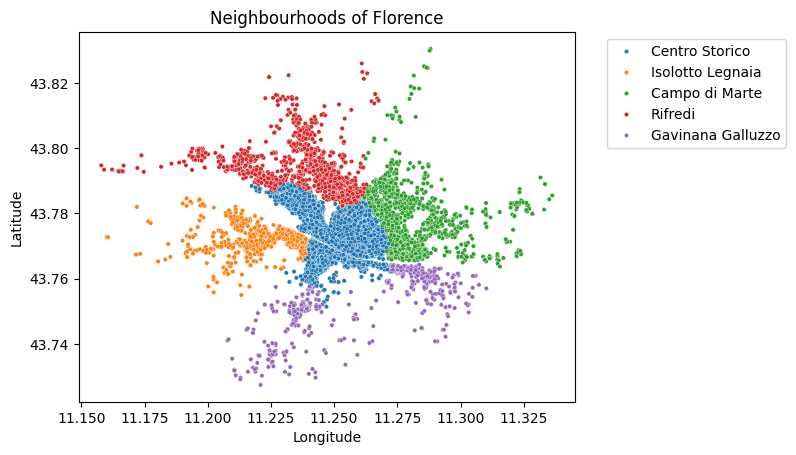

In [80]:
# Plot neighbourhoods by geographic location
sns.scatterplot(
    x="longitude", 
    y="latitude", 
    hue="neighbourhood",
    data=df,
    s=10
)
plt.title("Neighbourhoods of Florence")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# Remove geographic information of listings
df = df.drop(columns=["longitude", "latitude"])

### Target Variable (Price)

#### Missing Values

Missing price values are removed, because price is the target variable and cannot be imputed

In [14]:
missing_percent = df["price"].isna().mean()*100
print(f"Missing price values: {missing_percent:.1f}%")

# Remove rows with missing price values
df = df.dropna(subset=["price"])

Missing price values: 8.8%


#### Outliers

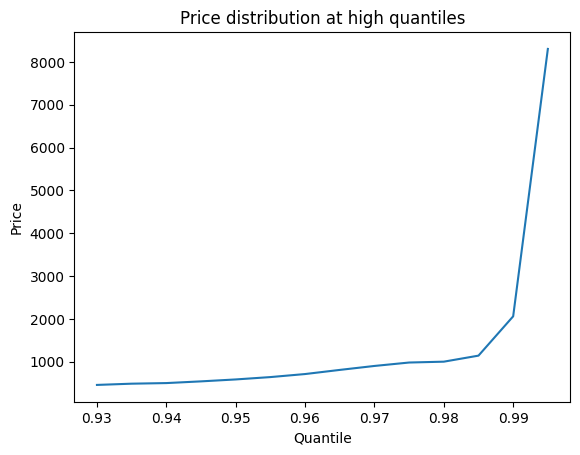

In [15]:
quantiles = np.arange(0.93, 1.0, 0.005)
values = df["price"].quantile(quantiles)
plt.plot(quantiles, values)
plt.xlabel("Quantile")
plt.ylabel("Price")
plt.title("Price distribution at high quantiles")
plt.show()

Listings above the 98.5th percentile are removed, because the quantile plot shows a steep increase after this point, indicating luxury properties that are not representative of typical Airbnb listings in Florence.

In [16]:
q985 = df["price"].quantile(0.985)
df = df[df["price"]<=q985]

The target-variable `price` is right-skewed and the log-transformation normalizes the distribution, as shown in the histograms below.

I will do the linear regression with the logarithm of the target variable, because for right-skewed distributions, the relations are often multiplicative and applying the logarithm transforms these into additive relations. 

It also often helps meeting the regression assumptions of normally distributed residuals and homoscedasticity, which will still be verified after fitting the model.

For these reasons, I will use `log_price` as the target variable during the exploration and analysis.

C:\Users\Besitzer\AppData\Local\Temp\ipykernel_30268\4072953357.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


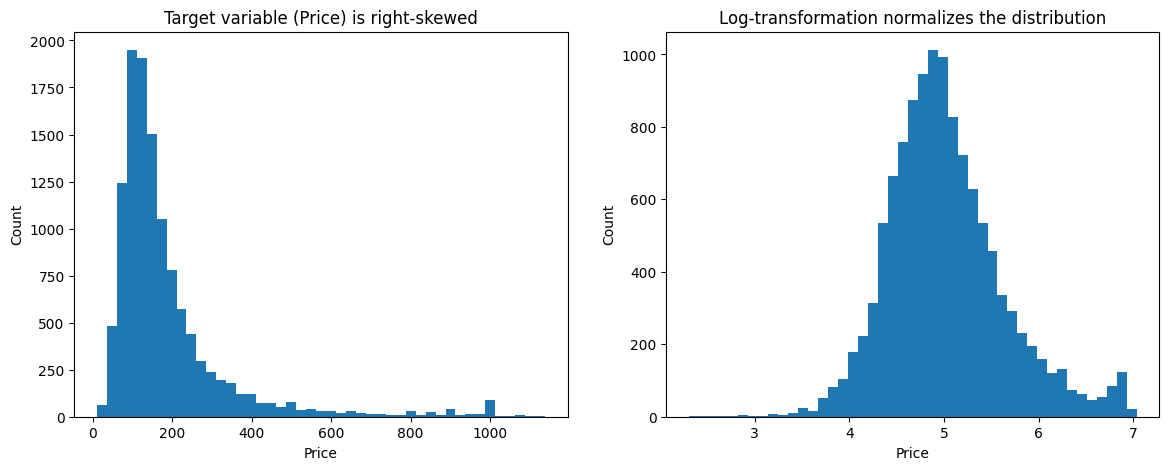

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df["log_price"] = np.log(df["price"])

ax[0].hist(df["price"], bins=45)
ax[0].set_xlabel("Price")
ax[0].set_ylabel("Count")
ax[0].set_title("Target variable (Price) is right-skewed")

ax[1].hist(df["log_price"], bins=45)
ax[1].set_xlabel("Price")
ax[1].set_ylabel("Count")
ax[1].set_title("Log-transformation normalizes the distribution")

fig.show()

### Handling Outliers

Hier auch oft log verwenden, um Effekt von Outliern zu verkleinern

In [81]:
df.columns

Index(['id', 'neighbourhood', 'room_type', 'price', 'number_of_reviews_ltm',
       'host_is_superhost', 'accommodates', 'bedrooms', 'beds',
       'instant_bookable', 'avg_rating', 'has_reviews'],
      dtype='str')

### Handling Missing Values

### Data Type Conversion

## Save Preprocessed Data to File

In [ ]:
df.to_csv("../data/processed/florence_processed.csv", index=False)